# Агентная SIR: устойчивость оптимизации

Повторим Borg MOEA на другом наборе seed, сохранив пять повторов и бюджет 120 секунд.

## Рабочее окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Независимый набор случайных реализаций

In [2]:
result = optimize_sir("sir_optimize_parameters__param"; seeds = 143:147)

(df = 53×5 DataFrame
 Row │ beta      detection_time  death_rate  peak        death_fraction 
     │ Float64   Int64           Float64     Float64     Float64        
─────┼──────────────────────────────────────────────────────────────────
   1 │ 0.5                    7   0.02       1.0            0.118467
   2 │ 0.305381               8   0.0103763  0.999867       0.05
   3 │ 0.530632               6   0.0129657  1.0            0.0778667
   4 │ 0.331604              12   0.0876372  1.0            0.388133
   5 │ 0.757493              13   0.0344303  1.0            0.202133
   6 │ 0.992581               3   0.0848965  0.800067       0.364
   7 │ 0.871729               7   0.0423062  1.0            0.2508
   8 │ 0.473076              14   0.0667385  1.0            0.3434
  ⋮  │    ⋮            ⋮             ⋮           ⋮             ⋮
  47 │ 0.28464                9   0.051672   0.999863       0.240533
  48 │ 0.903185               5   0.0782152  1.0            0.424867
  49 │ 0.448226

## Сравнение с базовой оптимизацией

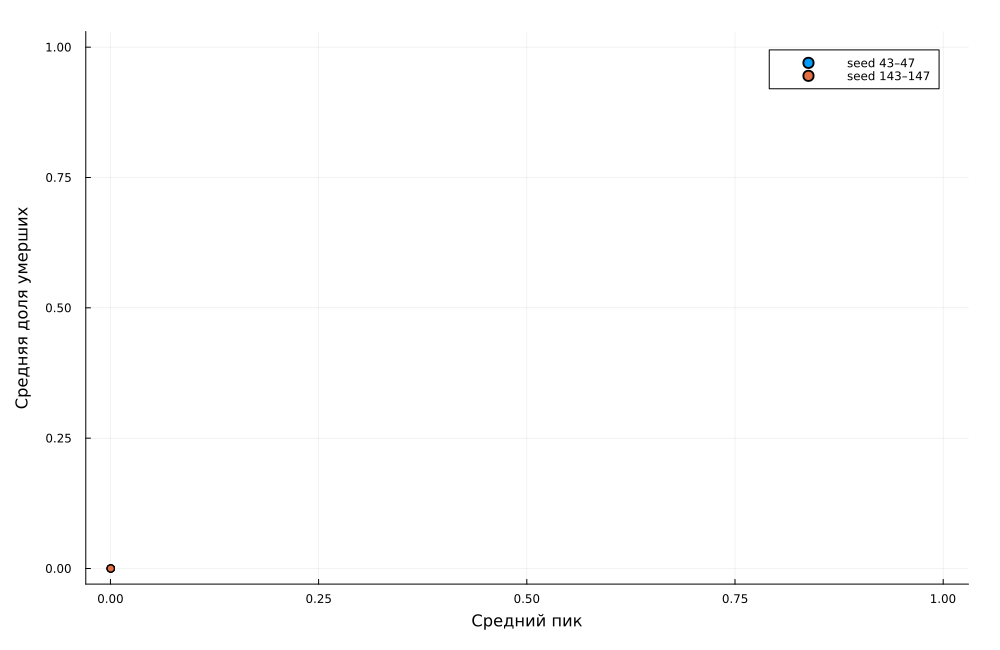

Row,beta,detection_time,death_rate,peak,death_fraction
,Float64,Int64,Float64,Float64,Float64
1,0.115295,4,0.0964811,0.0004,0.0
2,0.104035,4,0.0838149,0.0004,0.0


In [3]:
baseline = CSV.read(
    datafile("sir_optimize_parameters", "pareto.csv"),
    DataFrame,
)
figure = scatter(
    baseline.peak,
    baseline.death_fraction;
    label = "seed 43–47",
    xlabel = "Средний пик",
    ylabel = "Средняя доля умерших",
)
scatter!(
    figure,
    result.pareto.peak,
    result.pareto.death_fraction;
    label = "seed 143–147",
)
savefig(figure, imagefile("09-plot.png"))
display(figure)
result.pareto